# RL for Crypto Optimal Execution

**Execution environment**: local `uv run` on CPU. The small PPO MLP has no
meaningful GPU-heavy path.

This notebook demonstrates reinforcement learning for optimal execution using
**real crypto data** from perpetual futures markets. Unlike other notebooks in
this chapter that use synthetic data, this one applies RL concepts to actual
market data.

**Learning Outcomes**:
- LO2: Implement an optimal execution agent for 24/7 crypto markets
- LO3: Use premium index as an execution timing signal
- LO4: Compare RL-based execution with TWAP baseline on real data

**Book Reference**: Chapter 21, Section 21.4.

**Prerequisites**: `optimal_execution_ppo` and `calibration`.

**Key Features**:
- 24/7 market operation (no session filtering)
- Funding rate timing (8-hour windows on Binance)
- Premium index as state feature for execution timing
- Real hourly OHLCV data from crypto perpetual futures

**Scope Note**: The premium index is used here as a state variable for
conditional execution, not as a direct execution-cost term. This remains a
stylized real-data exercise rather than a production execution model.

In [1]:
"""RL for Crypto Optimal Execution - apply reinforcement learning to optimal execution using real crypto perpetual futures data."""

# Core imports
import json
import warnings
from datetime import UTC, datetime

import numpy as np
import polars as pl
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=DeprecationWarning)

import plotly.graph_objects as go
from crypto_execution_env import CryptoExecutionEnv

# RL frameworks
from plotly.subplots import make_subplots
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

from data import load_crypto_perps, load_crypto_premium
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
OUTPUT_DIR = get_output_dir(21, "crypto_execution_rl")

In [3]:
SYMBOLS = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "BNBUSDT", "XRPUSDT"]
START_DATE = "2022-01-01"
END_DATE = "2024-12-01"
EVAL_START_DATE = "2024-01-01"
TOTAL_SHARES = 100
EXECUTION_HORIZON = 24
TOTAL_TIMESTEPS = 200_000
EVAL_EPISODES = 20
RISK_AVERSION = 1e-4
SCHEDULE_PENALTY = 5e-4
EXPORT_RESULTS = False
SEED = 314  # Reproducible training across re-runs

In [4]:
set_global_seeds(SEED)

In [5]:
# Configuration
config = {
    "symbols": SYMBOLS,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "eval_start_date": EVAL_START_DATE,
    "total_shares": TOTAL_SHARES,  # In BTC terms, represents ~$10M at $100k/BTC
    "execution_horizon": EXECUTION_HORIZON,  # 24 hours for execution
    "total_timesteps": TOTAL_TIMESTEPS,
    "eval_episodes": EVAL_EPISODES,
    "risk_aversion": RISK_AVERSION,
    "schedule_penalty": SCHEDULE_PENALTY,
    "export_results": EXPORT_RESULTS,
}

print(f"Configuration: {config}")

Configuration: {'symbols': ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'BNBUSDT', 'XRPUSDT'], 'start_date': '2022-01-01', 'end_date': '2024-12-01', 'eval_start_date': '2024-01-01', 'total_shares': 100, 'execution_horizon': 24, 'total_timesteps': 200000, 'eval_episodes': 20, 'risk_aversion': 0.0001, 'schedule_penalty': 0.0005, 'export_results': False}


## 1. Load and Prepare Real Crypto Data

We load hourly OHLCV and premium index data from Binance perpetual futures.
The premium index measures the basis between perpetual and spot prices -
a key signal for funding rate arbitrage strategies.

In [6]:
print("Loading crypto market data...")

# Load hourly OHLCV data
ohlcv = load_crypto_perps(frequency="1h")
print(f"OHLCV shape: {ohlcv.shape}")

# Load premium index (8h frequency - forward-filled to match hourly OHLCV)
premium = load_crypto_premium()
print(f"Premium index shape (8h): {premium.shape}")

start_ts = datetime.fromisoformat(config["start_date"]).replace(tzinfo=UTC)
end_ts = datetime.fromisoformat(config["end_date"]).replace(tzinfo=UTC)

# Cast date literals to match column dtype to avoid resolution/timezone mismatches
# (e.g. Datetime('ms','UTC') vs Datetime('μs',None))
ohlcv_start = pl.lit(start_ts).cast(ohlcv["timestamp"].dtype)
ohlcv_end = pl.lit(end_ts).cast(ohlcv["timestamp"].dtype)
premium_start = pl.lit(start_ts).cast(premium["timestamp"].dtype)
premium_end = pl.lit(end_ts).cast(premium["timestamp"].dtype)

# Filter to configured symbols and date range
ohlcv = ohlcv.filter(
    (pl.col("symbol").is_in(config["symbols"]))
    & (pl.col("timestamp") >= ohlcv_start)
    & (pl.col("timestamp") <= ohlcv_end)
).sort(["symbol", "timestamp"])

premium = premium.filter(
    (pl.col("symbol").is_in(config["symbols"]))
    & (pl.col("timestamp") >= premium_start)
    & (pl.col("timestamp") <= premium_end)
).sort(["symbol", "timestamp"])

print(f"\nFiltered OHLCV: {ohlcv.shape}")
print(f"Filtered Premium: {premium.shape}")
print(f"Symbols: {ohlcv['symbol'].unique().to_list()}")
print(f"Date range: {ohlcv['timestamp'].min()} to {ohlcv['timestamp'].max()}")

Loading crypto market data...
OHLCV shape: (866484, 7)
Premium index shape (8h): (107839, 6)

Filtered OHLCV: (127565, 7)
Filtered Premium: (15956, 6)
Symbols: ['ETHUSDT', 'BTCUSDT', 'SOLUSDT', 'BNBUSDT', 'XRPUSDT']
Date range: 2022-01-01 00:00:00+00:00 to 2024-12-01 00:00:00+00:00


In [7]:
# Join OHLCV with premium index (asof join: 8h premium forward-filled to hourly)
data = ohlcv.sort(["symbol", "timestamp"]).join_asof(
    premium.select(["timestamp", "symbol", "premium_index_close"]).sort(["symbol", "timestamp"]),
    on="timestamp",
    by="symbol",
    strategy="backward",
    check_sortedness=False,
)

# Build decision-time features. At timestamp t, the current open and calendar
# are known; returns, volume, volatility, and premium use only completed bars.
data = (
    data.sort(["symbol", "timestamp"])
    .with_columns(
        [
            pl.col("close").pct_change().shift(1).over("symbol").alias("return_1h"),
            pl.col("close")
            .pct_change()
            .rolling_std(24)
            .shift(1)
            .over("symbol")
            .alias("volatility_24h"),
            pl.col("volume").shift(1).over("symbol").alias("observed_volume"),
            pl.col("volume").rolling_mean(24).shift(1).over("symbol").alias("avg_volume_24h"),
            pl.col("premium_index_close").shift(1).over("symbol"),
            pl.col("timestamp").dt.hour().alias("hour"),
            ((8 - (pl.col("timestamp").dt.hour() % 8)) % 8).alias("hours_to_funding"),
        ]
    )
    .drop_nulls()
)

The temporal split is sealed before either environment is constructed, so
training and reported evaluation episodes cannot sample the same hours.

In [8]:
eval_start_ts = pl.lit(datetime.fromisoformat(config["eval_start_date"]).replace(tzinfo=UTC)).cast(
    data["timestamp"].dtype
)
train_data = data.filter(pl.col("timestamp") < eval_start_ts)
evaluation_data = data.filter(pl.col("timestamp") >= eval_start_ts)
assert train_data["timestamp"].max() < evaluation_data["timestamp"].min()

print(f"\nPrepared data: {data.shape}")
print(
    f"Training window ends {train_data['timestamp'].max()}; "
    f"sealed evaluation starts {evaluation_data['timestamp'].min()}"
)
print(f"Columns: {data.columns}")
print(data.head(3))


Prepared data: (127440, 14)
Training window ends 2023-12-31 23:00:00+00:00; sealed evaluation starts 2024-01-01 00:00:00+00:00
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'symbol', 'premium_index_close', 'return_1h', 'volatility_24h', 'observed_volume', 'avg_volume_24h', 'hour', 'hours_to_funding']
shape: (3, 14)
┌───────────────┬────────┬────────┬────────┬───┬──────────────┬──────────────┬──────┬──────────────┐
│ timestamp     ┆ open   ┆ high   ┆ low    ┆ … ┆ observed_vol ┆ avg_volume_2 ┆ hour ┆ hours_to_fun │
│ ---           ┆ ---    ┆ ---    ┆ ---    ┆   ┆ ume          ┆ 4h           ┆ ---  ┆ ding         │
│ datetime[ms,  ┆ f64    ┆ f64    ┆ f64    ┆   ┆ ---          ┆ ---          ┆ i8   ┆ ---          │
│ UTC]          ┆        ┆        ┆        ┆   ┆ f64          ┆ f64          ┆      ┆ i8           │
╞═══════════════╪════════╪════════╪════════╪═══╪══════════════╪══════════════╪══════╪══════════════╡
│ 2022-01-02    ┆ 525.29 ┆ 525.59 ┆ 522.8  ┆ … ┆ 30728.41

## 2. Crypto Execution Environment

We create a gymnasium environment that:
- Uses real market data (OHLCV + premium index)
- Models 24/7 crypto market operation
- Incorporates funding rate timing (8-hour windows)
- Estimates market impact based on volume

### Crypto Execution Environment

`CryptoExecutionEnv` is a Gymnasium environment that simulates selling a large
position over a fixed horizon using real crypto market data. At each hourly step,
the agent observes a 7-dimensional state vector:

| Feature | Description |
|---------|-------------|
| `inventory_ratio` | Fraction of the original order still remaining |
| `time_ratio` | Fraction of the execution horizon still available |
| `volatility` | 24-hour rolling volatility (normalized) |
| `premium_index` | Perpetual-spot basis from Binance (normalized) |
| `volume_ratio` | Current volume relative to 24-hour average |
| `hour_of_day` | UTC hour (normalized to $[0, 1]$) |
| `hours_to_funding` | Hours until next Binance funding settlement |

The decision at hour $t$ uses the current open and features from completed
bars through $t-1$. The action is a scalar pace multiplier in $[0, 1]$ that scales a TWAP-like
reference schedule between `pace_min_multiplier` (0.5x) and `pace_max_multiplier`
(1.5x). Market impact follows a square-root-plus-linear model calibrated to
the participation rate. The reward is negative implementation shortfall
(in basis points) penalized by inventory risk and schedule deviation.


## 3. Benchmark Strategies

We implement true TWAP and a premium-aware pacing heuristic as baselines.

### TWAP Baseline

Time-Weighted Average Price divides the order equally across every step in the
horizon. It ignores market conditions entirely, making it a clean benchmark.

In [9]:
def twap_execution(env: CryptoExecutionEnv, reset_seed: int | None = None) -> dict:
    """
    Time-Weighted Average Price: sell equal amounts each period.
    """
    obs, _ = env.reset(seed=reset_seed)
    done = False

    while not done:
        if env.step_idx == env.horizon - 1:
            target_shares = env.remaining_shares
        else:
            target_shares = env.total_shares / env.horizon
        action = env.target_shares_to_action(target_shares)

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    return summarize_execution(env)

### Execution Summary Helper

Extracts total shortfall in basis points and forced-liquidation flag from a
completed episode. Used by all three strategies.

In [10]:
def summarize_execution(env: CryptoExecutionEnv) -> dict:
    forced_liquidation = any(h.get("forced_liquidation", False) for h in env.execution_history)
    return {
        "total_shortfall": env.total_cost,
        "shortfall_bps": (env.total_cost / (env.arrival_price * env.total_shares) * 10_000),
        "forced_liquidation": forced_liquidation,
        "history": env.execution_history,
    }

### Funding-Aware Heuristic

A premium-aware pacing rule that accelerates execution when the perpetual-spot
basis is rich and when the next funding settlement is imminent. This captures
the intuition that selling into positive premium reduces effective cost.

In [11]:
def funding_aware_execution(env: CryptoExecutionEnv, reset_seed: int | None = None) -> dict:
    """
    Premium-aware pacing: sell faster into rich premium and near funding,
    but keep executing throughout the horizon.
    """
    obs, _ = env.reset(seed=reset_seed)
    done = False

    while not done:
        market = env._get_market_state(env.start_idx + env.step_idx)
        if env.step_idx == env.horizon - 1:
            target_shares = env.remaining_shares
        else:
            base_rate = env.remaining_shares / max(env.horizon - env.step_idx, 1)
            premium_signal = np.clip(market.premium_index / 0.001, -1.0, 1.0)
            funding_multiplier = 1.25 if market.hours_to_funding <= 2 else 1.0
            target_shares = (
                base_rate * np.clip(1.0 + 0.5 * premium_signal, 0.5, 1.5) * funding_multiplier
            )
            target_shares = min(target_shares, env.remaining_shares)
        action = env.target_shares_to_action(target_shares)

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    return summarize_execution(env)

## 4. Train PPO Agent

We train a PPO agent to learn optimal execution timing using the
real crypto market features.

In [12]:
print("Creating training environment...")


def make_env(seed: int = 42):
    def _init():
        return CryptoExecutionEnv(
            market_data=train_data,
            symbol="BTCUSDT",
            total_shares=config["total_shares"],
            horizon=config["execution_horizon"],
            risk_aversion=config["risk_aversion"],
            schedule_penalty=config["schedule_penalty"],
            seed=seed,
        )

    return _init


# Create vectorized environment
env = DummyVecEnv([make_env(seed=SEED)])

print(
    "Training environment created with "
    f"{train_data.filter(pl.col('symbol') == 'BTCUSDT').height} hours of point-in-time data"
)

Creating training environment...
Training environment created with 17495 hours of point-in-time data


In [13]:
model = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    clip_range=0.2,
    ent_coef=0.01,  # Moderate entropy for exploration without degenerate policies
    seed=SEED,  # Reproducible training
    verbose=0,
    device="cpu",  # Small MLP; CPU is faster than GPU for SB3
)

model.learn(total_timesteps=config["total_timesteps"])
print("\nTraining complete!")


Training complete!


## 5. Evaluate Strategies

### PPO Execution Strategy

Wraps the trained PPO model into the same execution interface used by
TWAP and the funding-aware heuristic, running deterministic inference.

In [14]:
def ppo_execution(env: CryptoExecutionEnv, reset_seed: int | None = None) -> dict:
    """Execute using trained PPO agent."""
    obs, _ = env.reset(seed=reset_seed)
    done = False

    while not done:
        obs_tensor = np.array([env._get_obs()])
        action, _ = model.predict(obs_tensor, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(
            float(np.asarray(action).reshape(-1)[0])
        )
        done = terminated or truncated

    return summarize_execution(env)

### Multi-Episode Evaluation

Runs a strategy over multiple random episodes and collects shortfall
statistics, forced-liquidation rates, and per-step execution paths
for trajectory visualization.

**Scope note**: training episodes end before `EVAL_START_DATE`; every result
below uses the later sealed window. This is a historical out-of-sample
simulator test, not a claim about live fills or deployable capacity.

Each episode contributes its diagnostics and complete path to the aggregate
evaluation table while retaining its deterministic seed.

In [15]:
def append_evaluation_path(
    all_paths: list[dict], history: list[dict], strategy_name: str, episode_id: int, seed: int
) -> None:
    """Append one identified episode path to the aggregate evaluation records."""
    all_paths.extend(
        {
            "strategy": strategy_name,
            "episode_id": episode_id,
            "episode_seed": seed,
            **row,
        }
        for row in history
    )

In [16]:
def evaluate_strategy(strategy_name: str, strategy_fn, n_episodes: int = 20, seed_base: int = 1000):
    """Evaluate a strategy over multiple episodes."""
    shortfalls = []
    forced_liqs = []
    all_paths = []
    last_step_shares = []
    final_quarter_shares = []

    for i in range(n_episodes):
        episode_seed = seed_base + i
        env = CryptoExecutionEnv(
            market_data=evaluation_data,
            symbol="BTCUSDT",
            total_shares=config["total_shares"],
            horizon=config["execution_horizon"],
            risk_aversion=config["risk_aversion"],
            schedule_penalty=config["schedule_penalty"],
            seed=episode_seed,
        )
        result = strategy_fn(env, reset_seed=episode_seed)
        shortfalls.append(result["shortfall_bps"])
        forced_liqs.append(result["forced_liquidation"])
        history = result["history"]
        last_step_shares.append(float(history[-1]["shares_sold"]) / env.total_shares)
        final_quarter_cutoff = max(env.horizon - env.horizon // 4, 0)
        final_quarter_volume = sum(
            float(h["shares_sold"]) for h in history if int(h["step"]) >= final_quarter_cutoff
        )
        final_quarter_shares.append(final_quarter_volume / env.total_shares)
        append_evaluation_path(all_paths, history, strategy_name, i, episode_seed)

    summary = {
        "mean_bps": np.mean(shortfalls),
        "std_bps": np.std(shortfalls),
        "min_bps": np.min(shortfalls),
        "max_bps": np.max(shortfalls),
        "forced_liq_rate": float(np.mean(forced_liqs)),
        "avg_last_step_share_pct": 100 * float(np.mean(last_step_shares)),
        "avg_final_quarter_share_pct": 100 * float(np.mean(final_quarter_shares)),
    }
    return summary, all_paths

In [17]:
print("\nEvaluating strategies on real crypto data...")

results = {}
evaluation_paths = []
for name, fn in [
    ("TWAP", twap_execution),
    ("Funding-Aware", funding_aware_execution),
    ("PPO", ppo_execution),
]:
    results[name], strategy_paths = evaluate_strategy(
        name,
        fn,
        n_episodes=config["eval_episodes"],
    )
    evaluation_paths.extend(strategy_paths)
    print(
        f"{name:15s}: {results[name]['mean_bps']:7.2f} +/- {results[name]['std_bps']:6.2f} bps"
        f" | forced liquidation: {results[name]['forced_liq_rate'] * 100:5.1f}%"
        f" | last step share: {results[name]['avg_last_step_share_pct']:5.1f}%"
    )


Evaluating strategies on real crypto data...
TWAP           :   46.24 +/- 132.35 bps | forced liquidation:   0.0% | last step share:   4.4%
Funding-Aware  :   45.06 +/- 132.71 bps | forced liquidation:   0.0% | last step share:   5.6%


PPO            :   41.10 +/- 113.15 bps | forced liquidation:   0.0% | last step share:   2.6%


## 6. Visualize Execution Trajectories

In [18]:
evaluation_df = pl.DataFrame(evaluation_paths).with_columns(
    [
        pl.col("shortfall").cum_sum().over(["strategy", "episode_id"]).alias("cum_shortfall"),
        (pl.col("premium_index") * 100).alias("premium_pct"),
    ]
)
trajectory_stats = (
    evaluation_df.group_by(["strategy", "step"])
    .agg(
        [
            pl.col("shares_sold").mean().alias("mean_shares_sold"),
            pl.col("remaining").mean().alias("mean_remaining"),
            pl.col("cum_shortfall").mean().alias("mean_cum_shortfall"),
            pl.col("premium_pct").mean().alias("mean_premium_pct"),
            pl.col("hours_to_funding").mean().alias("mean_hours_to_funding"),
        ]
    )
    .sort(["strategy", "step"])
)

In [19]:
# Create visualization
fig = make_subplots(
    rows=4,
    cols=1,
    subplot_titles=[
        "Average execution rate (shares/hour)",
        "Average remaining inventory",
        "Average premium index",
        "Average cumulative implementation shortfall",
    ],
    vertical_spacing=0.10,
)

colors = {
    "TWAP": COLORS["blue"],
    "Funding-Aware": COLORS["amber"],
    "PPO": COLORS["positive"],
}

A small trace helper keeps each panel definition identical across strategies
while allowing the premium panel to retain a single shared path.

In [20]:
def add_panel_line(fig, x, y, name, color, row, *, showlegend=False, dash=None):
    """Add one consistently styled line to a trajectory panel."""
    line = dict(color=color)
    if dash is not None:
        line["dash"] = dash
    fig.add_trace(
        go.Scatter(x=x, y=y, name=name, line=line, showlegend=showlegend, legendgroup=name),
        row=row,
        col=1,
    )

In [21]:
def _add_strategy_traces(fig, trajectory_stats, colors):
    """Add execution rate, inventory, premium, and shortfall traces per strategy."""
    for name in colors:
        strategy_df = trajectory_stats.filter(pl.col("strategy") == name).sort("step")
        if strategy_df.is_empty():
            continue
        steps = strategy_df["step"].to_list()
        shares = strategy_df["mean_shares_sold"].to_list()
        remaining = strategy_df["mean_remaining"].to_list()
        premium = strategy_df["mean_premium_pct"].to_list()
        cum_shortfall = strategy_df["mean_cum_shortfall"].to_list()

        add_panel_line(fig, steps, shares, name, colors[name], 1, showlegend=True)
        add_panel_line(fig, steps, remaining, name, colors[name], 2)

        # Premium index (only show once because the market path is shared by seed)
        if name == "TWAP":
            add_panel_line(
                fig,
                steps,
                premium,
                "Premium Index",
                COLORS["neutral"],
                3,
                showlegend=True,
                dash="dot",
            )

        add_panel_line(fig, steps, cum_shortfall, name, colors[name], 4)


_add_strategy_traces(fig, trajectory_stats, colors)

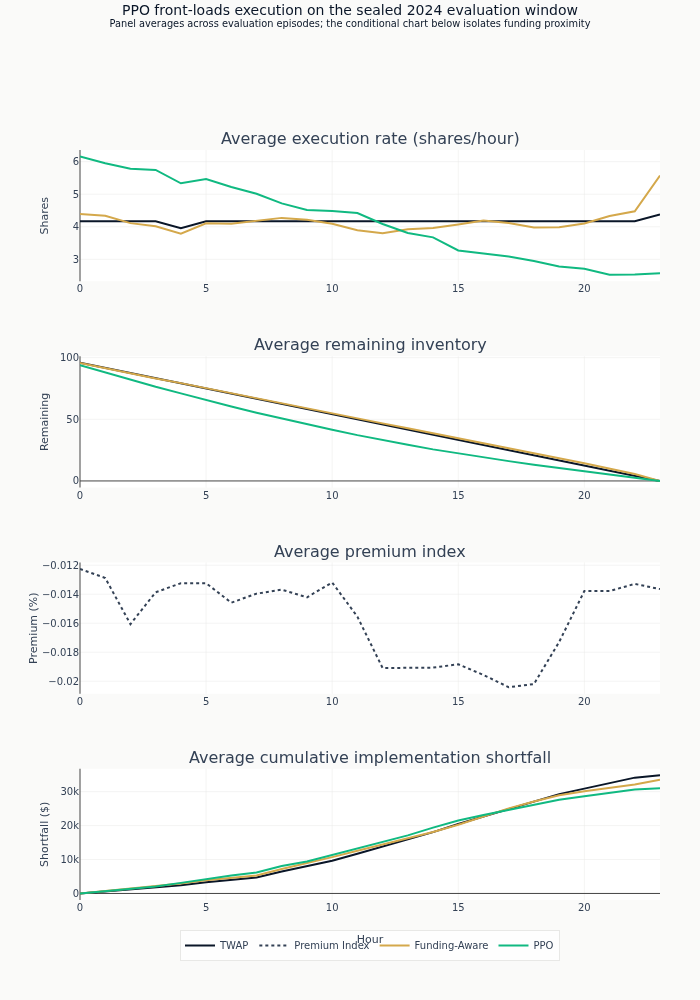

In [22]:
ppo_profile = trajectory_stats.filter(pl.col("strategy") == "PPO").sort("step")
profile_quarter = max(ppo_profile.height // 4, 1)
early_rate = float(ppo_profile.head(profile_quarter)["mean_shares_sold"].mean())
late_rate = float(ppo_profile.tail(profile_quarter)["mean_shares_sold"].mean())
profile_direction = "front-loads" if early_rate > late_rate else "back-loads"
fig.update_layout(
    title=dict(
        text=f"PPO {profile_direction} execution on the sealed 2024 evaluation window<br>"
        "<sup>Panel averages across evaluation episodes; the conditional chart below isolates funding proximity</sup>",
        y=0.985,
        yanchor="top",
    ),
    height=1000,
    margin=dict(t=150, b=100, r=40),
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.04,
        xanchor="center",
        x=0.5,
    ),
)

fig.update_yaxes(title_text="Shares", row=1, col=1)
fig.update_yaxes(title_text="Remaining", row=2, col=1)
fig.update_yaxes(title_text="Premium (%)", row=3, col=1)
fig.update_yaxes(title_text="Shortfall ($)", row=4, col=1)
fig.update_xaxes(title_text="Hour", row=4, col=1)

fig.show()

## 7. Failure-Mode Diagnostic

Forced liquidation is the main failure mode for compact RL execution policies.

In [23]:
diagnostic_data = [
    {
        "Strategy": name,
        "Forced Liq %": f"{results[name]['forced_liq_rate'] * 100:.1f}",
        "Final Quarter Vol %": f"{results[name]['avg_final_quarter_share_pct']:.1f}",
    }
    for name in ["TWAP", "Funding-Aware", "PPO"]
]
pl.DataFrame(diagnostic_data)

Strategy,Forced Liq %,Final Quarter Vol %
str,str,str
"""TWAP""","""0.0""","""25.2"""
"""Funding-Aware""","""0.0""","""26.4"""
"""PPO""","""0.0""","""16.1"""


A high forced-liquidation rate indicates that the policy is delaying too much
execution until the end of the horizon.

## 8. Pooled Conditional Analysis Across Evaluation Episodes

Analyze how the PPO agent conditions its execution on premium states by
pooling every step of all PPO evaluation episodes (not a single path). This
is a descriptive conditional diagnostic, not a stable ranking result.

### PPO Behavior by Premium Index Level

In [24]:
ppo_history = evaluation_df.filter(pl.col("strategy") == "PPO").to_dicts()

high_premium_trades = [h for h in ppo_history if h["premium_index"] > 0.0005]
low_premium_trades = [h for h in ppo_history if h["premium_index"] < -0.0005]
neutral_premium_trades = [h for h in ppo_history if -0.0005 <= h["premium_index"] <= 0.0005]

premium_rows = []
if high_premium_trades:
    rate = np.mean([h["shares_sold"] for h in high_premium_trades])
    premium_rows.append({"state": "High (> 5 bps)", "shares_per_hour": float(rate)})
if neutral_premium_trades:
    rate = np.mean([h["shares_sold"] for h in neutral_premium_trades])
    premium_rows.append({"state": "Neutral", "shares_per_hour": float(rate)})
if low_premium_trades:
    rate = np.mean([h["shares_sold"] for h in low_premium_trades])
    premium_rows.append({"state": "Low (< -5 bps)", "shares_per_hour": float(rate)})

premium_summary = pl.DataFrame(premium_rows)

### PPO Behavior by Funding Time Proximity

In [25]:
near_funding = [h for h in ppo_history if h["hours_to_funding"] <= 2]
far_funding = [h for h in ppo_history if h["hours_to_funding"] > 2]

funding_rows = []
if near_funding:
    rate = np.mean([h["shares_sold"] for h in near_funding])
    funding_rows.append({"state": "Within 2 hours", "shares_per_hour": float(rate)})
if far_funding:
    rate = np.mean([h["shares_sold"] for h in far_funding])
    funding_rows.append({"state": "More than 2 hours", "shares_per_hour": float(rate)})

funding_summary = pl.DataFrame(funding_rows)

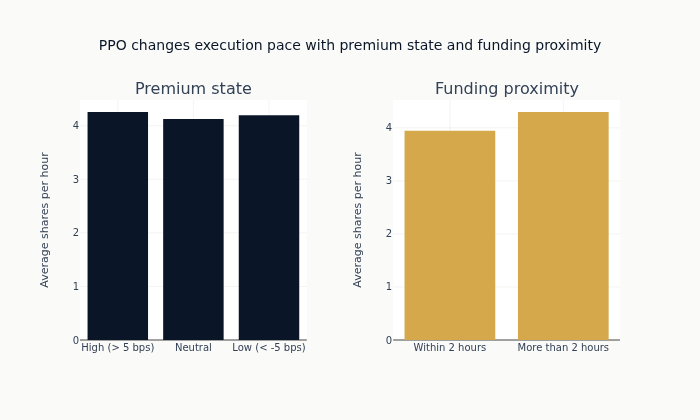

In [26]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Premium state", "Funding proximity"),
    horizontal_spacing=0.16,
)
fig.add_trace(
    go.Bar(
        x=premium_summary["state"].to_list(),
        y=premium_summary["shares_per_hour"].to_list(),
        marker_color=COLORS["blue"],
        name="Premium state",
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(
        x=funding_summary["state"].to_list(),
        y=funding_summary["shares_per_hour"].to_list(),
        marker_color=COLORS["amber"],
        name="Funding proximity",
    ),
    row=1,
    col=2,
)
fig.update_layout(
    title="PPO changes execution pace with premium state and funding proximity",
    height=420,
    showlegend=False,
)
fig.update_yaxes(title_text="Average shares per hour", rangemode="tozero", row=1, col=1)
fig.update_yaxes(title_text="Average shares per hour", rangemode="tozero", row=1, col=2)
fig.show()

## 9. Summary and Results Export

### Strategy Comparison

In [27]:
summary_data = []
for name, r in results.items():
    summary_data.append(
        {
            "Strategy": name,
            "Mean IS (bps)": f"{r['mean_bps']:.2f}",
            "Std (bps)": f"{r['std_bps']:.2f}",
            "Best (bps)": f"{r['min_bps']:.2f}",
            "Worst (bps)": f"{r['max_bps']:.2f}",
            "Forced Liq %": f"{100 * r['forced_liq_rate']:.0f}",
            "Last Step %": f"{r['avg_last_step_share_pct']:.1f}",
        }
    )

summary_df = pl.DataFrame(summary_data)
summary_df

Strategy,Mean IS (bps),Std (bps),Best (bps),Worst (bps),Forced Liq %,Last Step %
str,str,str,str,str,str,str
"""TWAP""","""46.24""","""132.35""","""-296.80""","""320.60""","""0""","""4.4"""
"""Funding-Aware""","""45.06""","""132.71""","""-294.89""","""294.30""","""0""","""5.6"""
"""PPO""","""41.10""","""113.15""","""-254.22""","""293.54""","""0""","""2.6"""


Illustrative mean implementation shortfall for this run. Treat this notebook
as a conditional execution example, not a locked ranking. Negative shortfall
means the realized path allowed sales above the arrival price.

In [28]:
for name in ["TWAP", "Funding-Aware", "PPO"]:
    print(f"{name}: {results[name]['mean_bps']:.2f} bps")

TWAP: 46.24 bps
Funding-Aware: 45.06 bps
PPO: 41.10 bps


In [29]:
if config["export_results"]:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    evaluation_df.write_parquet(OUTPUT_DIR / "rl_execution_results.parquet")
    print(f"\nResults saved to {OUTPUT_DIR / 'rl_execution_results.parquet'}")

    summary_export = pl.DataFrame(
        [
            {
                "strategy": name,
                "mean_bps": r["mean_bps"],
                "std_bps": r["std_bps"],
                "min_bps": r["min_bps"],
                "max_bps": r["max_bps"],
                "forced_liq_rate": r["forced_liq_rate"],
                "avg_last_step_share_pct": r["avg_last_step_share_pct"],
                "avg_final_quarter_share_pct": r["avg_final_quarter_share_pct"],
            }
            for name, r in results.items()
        ]
    )
    summary_export.write_parquet(OUTPUT_DIR / "rl_execution_summary.parquet")
    print(f"Summary saved to {OUTPUT_DIR / 'rl_execution_summary.parquet'}")

## Key Takeaways

In [30]:
best_mean = min(results, key=lambda name: results[name]["mean_bps"])
strategy_lines = "\n".join(
    f"- **{name}**: mean shortfall {results[name]['mean_bps']:.1f} bps, standard deviation "
    f"{results[name]['std_bps']:.1f} bps, final-quarter volume "
    f"{results[name]['avg_final_quarter_share_pct']:.1f}%, and last-hour volume "
    f"{results[name]['avg_last_step_share_pct']:.1f}%."
    for name in ["TWAP", "Funding-Aware", "PPO"]
)
premium_rates = dict(zip(premium_summary["state"], premium_summary["shares_per_hour"], strict=True))
funding_rates = dict(zip(funding_summary["state"], funding_summary["shares_per_hour"], strict=True))
display(
    Markdown(
        f"""
The 2024 sealed evaluation window produces these strategy diagnostics:

{strategy_lines}

**{best_mean}** has the lowest mean shortfall in this run, but the dispersion is large enough that
the ordering is not a locked ranking. Negative shortfall means the realized path permitted sales
above the arrival price.

PPO sells {premium_rates.get("High (> 5 bps)", float("nan")):.2f} shares per hour in high-premium
states and {premium_rates.get("Low (< -5 bps)", float("nan")):.2f} in low-premium states. Its rate is
{funding_rates.get("Within 2 hours", float("nan")):.2f} within two hours of funding and
{funding_rates.get("More than 2 hours", float("nan")):.2f} farther away. These are descriptive
conditional diagnostics, not causal estimates of funding effects.

**Next**: See `optimal_execution_ppo` for the synthetic-data counterpart. Section 21.4 develops the
execution interpretation.
"""
    )
)


The 2024 sealed evaluation window produces these strategy diagnostics:

- **TWAP**: mean shortfall 46.2 bps, standard deviation 132.3 bps, final-quarter volume 25.2%, and last-hour volume 4.4%.
- **Funding-Aware**: mean shortfall 45.1 bps, standard deviation 132.7 bps, final-quarter volume 26.4%, and last-hour volume 5.6%.
- **PPO**: mean shortfall 41.1 bps, standard deviation 113.1 bps, final-quarter volume 16.1%, and last-hour volume 2.6%.

**PPO** has the lowest mean shortfall in this run, but the dispersion is large enough that
the ordering is not a locked ranking. Negative shortfall means the realized path permitted sales
above the arrival price.

PPO sells 4.26 shares per hour in high-premium
states and 4.19 in low-premium states. Its rate is
3.95 within two hours of funding and
4.30 farther away. These are descriptive
conditional diagnostics, not causal estimates of funding effects.

**Next**: See `optimal_execution_ppo` for the synthetic-data counterpart. Section 21.4 develops the
execution interpretation.


In [31]:
completion_record = {
    "train_rows": train_data.height,
    "evaluation_rows": evaluation_data.height,
    "evaluation_episodes": config["eval_episodes"],
    "strategies": {
        name: {
            "mean_bps": float(results[name]["mean_bps"]),
            "std_bps": float(results[name]["std_bps"]),
            "forced_liq_rate": float(results[name]["forced_liq_rate"]),
        }
        for name in ["TWAP", "Funding-Aware", "PPO"]
    },
    "ppo_profile": {
        "direction": profile_direction,
        "high_premium_rate": float(premium_rates.get("High (> 5 bps)", float("nan"))),
        "low_premium_rate": float(premium_rates.get("Low (< -5 bps)", float("nan"))),
        "near_funding_rate": float(funding_rates.get("Within 2 hours", float("nan"))),
        "far_funding_rate": float(funding_rates.get("More than 2 hours", float("nan"))),
    },
}
print("COMPLETION_RECORD=" + json.dumps(completion_record, sort_keys=True))

COMPLETION_RECORD={"evaluation_episodes": 20, "evaluation_rows": 40205, "ppo_profile": {"direction": "front-loads", "far_funding_rate": 4.298508737982755, "high_premium_rate": 4.256345525233234, "low_premium_rate": 4.194207415255667, "near_funding_rate": 3.9469298811398543}, "strategies": {"Funding-Aware": {"forced_liq_rate": 0.0, "mean_bps": 45.05750852922272, "std_bps": 132.70668723202218}, "PPO": {"forced_liq_rate": 0.0, "mean_bps": 41.09837043902864, "std_bps": 113.14575631608263}, "TWAP": {"forced_liq_rate": 0.0, "mean_bps": 46.244560780105076, "std_bps": 132.34821479613998}}, "train_rows": 87235}
